In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
plt.rcParams['figure.figsize'] = (10, 4)

sample mean = 99.932  (true 100.0)
sample std  = 14.932  (true 15.0)


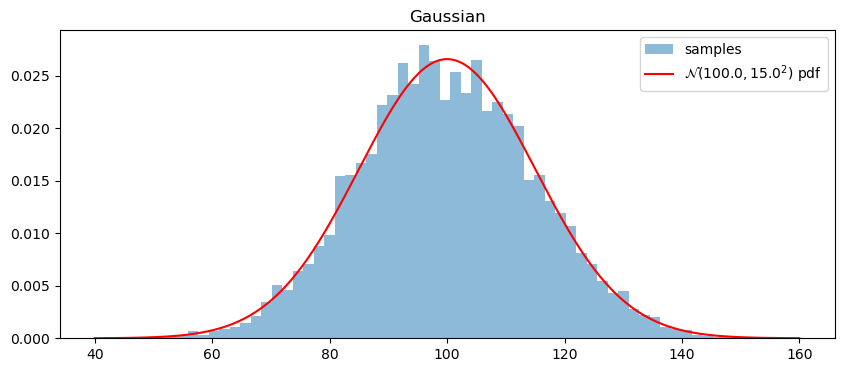

In [2]:
mu_true, sigma_true = 100.0, 15.0
N = 5000
samples_g = rng.normal(mu_true, sigma_true, size=N)

print(f'sample mean = {samples_g.mean():.3f}  (true {mu_true})')
print(f'sample std  = {samples_g.std(ddof=1):.3f}  (true {sigma_true})')

xs = np.linspace(40, 160, 400)
pdf = 1/(np.sqrt(2*np.pi)*sigma_true) * np.exp(-0.5*((xs-mu_true)/sigma_true)**2)

plt.hist(samples_g, bins=60, density=True, alpha=0.5, label='samples')
plt.plot(xs, pdf, 'r-', label=f'$\mathcal{{N}}({mu_true}, {sigma_true}^2)$ pdf')
plt.legend(); plt.title('Gaussian'); plt.show()

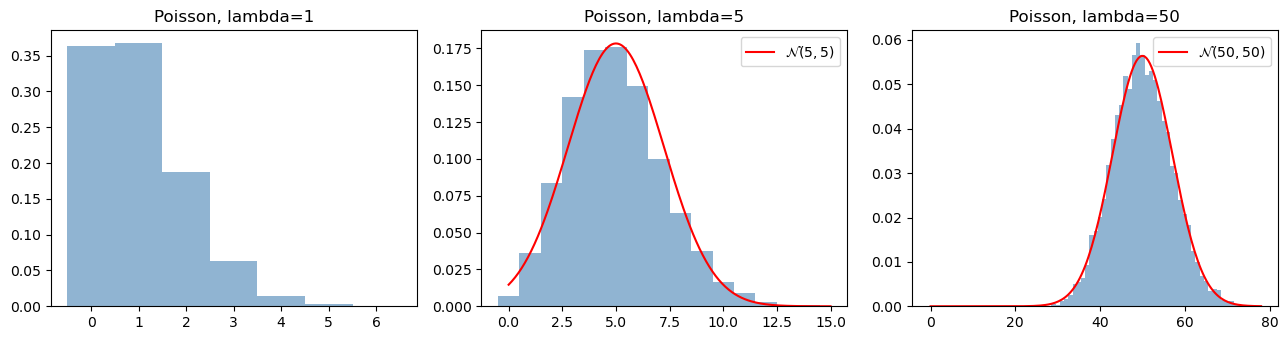

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, lam in zip(axes, [1, 5, 50]):
    samples_p = rng.poisson(lam, size=10000)
    ks = np.arange(0, samples_p.max()+1)
    ax.hist(samples_p, bins=ks-0.5, density=True, alpha=0.6, color='steelblue')
    if lam >= 5:
        sig = np.sqrt(lam)
        xs = np.linspace(0, samples_p.max(), 200)
        ax.plot(xs, 1/(np.sqrt(2*np.pi)*sig)*np.exp(-0.5*((xs-lam)/sig)**2),
                'r-', label=f'$\mathcal{{N}}({lam}, {lam})$')
        ax.legend()
    ax.set_title(f'Poisson, lambda={lam}')
plt.tight_layout();  plt.show()

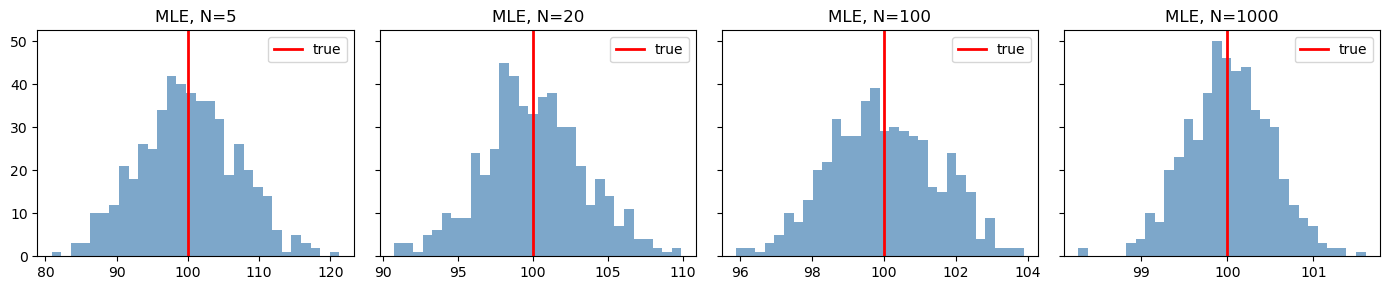

In [7]:

sigma_known = 15.0
mu_true_local = 100.0

Ns = [5, 20, 100, 1000]
fig, axes = plt.subplots(1, len(Ns), figsize=(14, 3), sharey=True)
for ax, N in zip(axes, Ns):
    estimates = [rng.normal(mu_true_local, sigma_known, size=N).mean() for _ in range(500)]
    ax.hist(estimates, bins=30, color='steelblue', alpha=0.7)
    ax.axvline(mu_true_local, color='red', lw=2, label='true')
    ax.set_title(f'MLE, N={N}'); ax.legend()
plt.tight_layout(); plt.show()

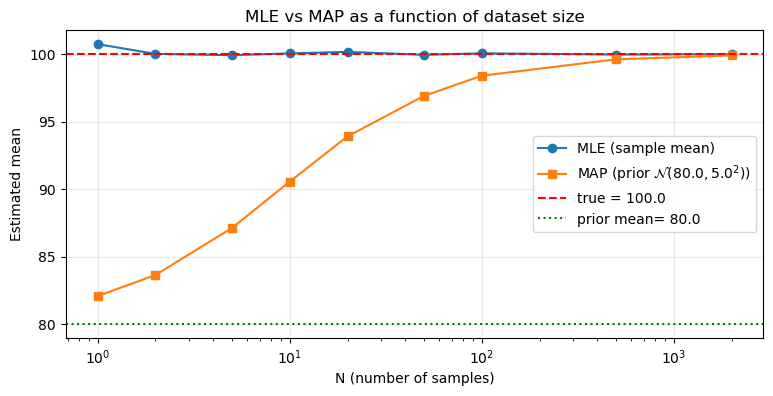

In [10]:
def map_mean_gaussian(samples, sigma, mu0, sigma0):
    N = len(samples)
    xbar = samples.mean()
    w_data  = sigma0**2 / (sigma0**2 + sigma**2/N)
    w_prior = (sigma**2/N) / (sigma0**2 + sigma**2/N)
    return w_data * xbar + w_prior * mu0

# Pick a prior that disagrees with the truth, to see the shrinkage explicitly.
mu0, sigma0 = 80.0, 5.0   # prior thinks mean is 80, fairly confidently
sigma_known = 15.0
mu_true_local = 100.0

Ns = np.array([1, 2, 5, 10, 20, 50, 100, 500, 2000])
mles, maps = [], []
for N in Ns:
    # average over 500 random data sets for a clean curve
    mle_runs = []
    map_runs = []
    for _ in range(500):
        s = rng.normal(mu_true_local, sigma_known, size=N)
        mle_runs.append(s.mean())
        map_runs.append(map_mean_gaussian(s, sigma_known, mu0, sigma0))
    mles.append(np.mean(mle_runs))
    maps.append(np.mean(map_runs))

plt.figure(figsize=(9, 4))
plt.semilogx(Ns, mles, 'o-', label='MLE (sample mean)')
plt.semilogx(Ns, maps, 's-', label=f'MAP (prior $\mathcal{{N}}({mu0},{sigma0}^2)$)')
plt.axhline(mu_true_local, color='red', linestyle='--', label=f'true = {mu_true_local}')
plt.axhline(mu0, color='green', linestyle=':', label=f'prior mean= {mu0}')
plt.xlabel('N (number of samples)'); plt.ylabel('Estimated mean')
plt.title('MLE vs MAP as a function of dataset size')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

sigma0=50 this means w_data tends to 1 and w_prior tends to 0

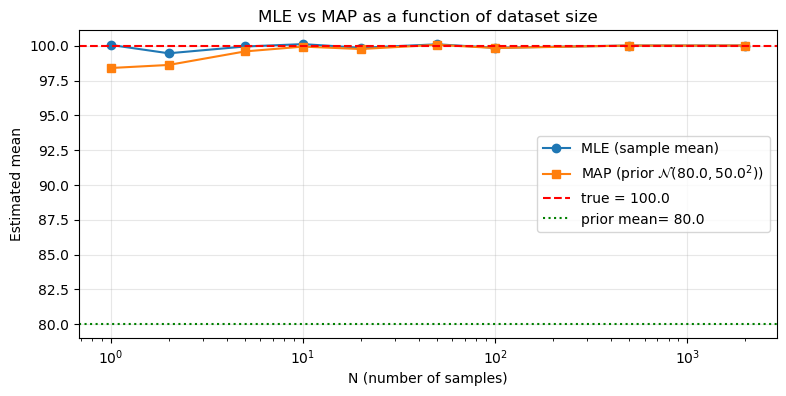

In [12]:
def map_mean_gaussian(samples, sigma, mu0, sigma0):
    N = len(samples)
    xbar = samples.mean()
    w_data  = sigma0**2 / (sigma0**2 + sigma**2/N)
    w_prior = (sigma**2/N) / (sigma0**2 + sigma**2/N)
    return w_data * xbar + w_prior * mu0

# Pick a prior that disagrees with the truth, to see the shrinkage explicitly.
mu0, sigma0 = 80.0, 50.0   # prior thinks mean is 80, fairly confidently
sigma_known = 15.0
mu_true_local = 100.0

Ns = np.array([1, 2, 5, 10, 20, 50, 100, 500, 2000])
mles, maps = [], []
for N in Ns:
    # average over 500 random data sets for a clean curve
    mle_runs = []
    map_runs = []
    for _ in range(500):
        s = rng.normal(mu_true_local, sigma_known, size=N)
        mle_runs.append(s.mean())
        map_runs.append(map_mean_gaussian(s, sigma_known, mu0, sigma0))
    mles.append(np.mean(mle_runs))
    maps.append(np.mean(map_runs))

plt.figure(figsize=(9, 4))
plt.semilogx(Ns, mles, 'o-', label='MLE (sample mean)')
plt.semilogx(Ns, maps, 's-', label=f'MAP (prior $\mathcal{{N}}({mu0},{sigma0}^2)$)')
plt.axhline(mu_true_local, color='red', linestyle='--', label=f'true = {mu_true_local}')
plt.axhline(mu0, color='green', linestyle=':', label=f'prior mean= {mu0}')
plt.xlabel('N (number of samples)'); plt.ylabel('Estimated mean')
plt.title('MLE vs MAP as a function of dataset size')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

A weak prior was created by increasing the prior standard deviation from 5 to 50. Since the prior variance became very large, the prior carried little information about the mean. Consequently, the MAP estimate relied almost entirely on the observed data and closely matched the MLE even for small sample sizes. This confirms that weak priors have minimal influence on Bayesian estimates.

In [ ]:
When sigma0 = 1

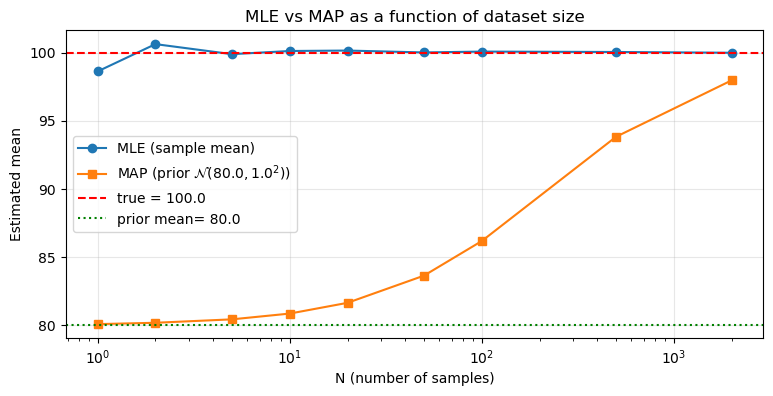

In [13]:
def map_mean_gaussian(samples, sigma, mu0, sigma0):
    N = len(samples)
    xbar = samples.mean()
    w_data  = sigma0**2 / (sigma0**2 + sigma**2/N)
    w_prior = (sigma**2/N) / (sigma0**2 + sigma**2/N)
    return w_data * xbar + w_prior * mu0

# Pick a prior that disagrees with the truth, to see the shrinkage explicitly.
mu0, sigma0 = 80.0, 1.0   # prior thinks mean is 80, fairly confidently
sigma_known = 15.0
mu_true_local = 100.0

Ns = np.array([1, 2, 5, 10, 20, 50, 100, 500, 2000])
mles, maps = [], []
for N in Ns:
    # average over 500 random data sets for a clean curve
    mle_runs = []
    map_runs = []
    for _ in range(500):
        s = rng.normal(mu_true_local, sigma_known, size=N)
        mle_runs.append(s.mean())
        map_runs.append(map_mean_gaussian(s, sigma_known, mu0, sigma0))
    mles.append(np.mean(mle_runs))
    maps.append(np.mean(map_runs))

plt.figure(figsize=(9, 4))
plt.semilogx(Ns, mles, 'o-', label='MLE (sample mean)')
plt.semilogx(Ns, maps, 's-', label=f'MAP (prior $\mathcal{{N}}({mu0},{sigma0}^2)$)')
plt.axhline(mu_true_local, color='red', linestyle='--', label=f'true = {mu_true_local}')
plt.axhline(mu0, color='green', linestyle=':', label=f'prior mean= {mu0}')
plt.xlabel('N (number of samples)'); plt.ylabel('Estimated mean')
plt.title('MLE vs MAP as a function of dataset size')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

A very strong prior was created by setting sigma0=1. Since the prior variance was extremely small, the MAP estimate was heavily influenced by the prior mean of 80. For small sample sizes, the MAP estimate remained close to 80 even though the true mean was 100. As the number of observations increased, the influence of the data grew and the MAP estimate gradually approached the MLE.

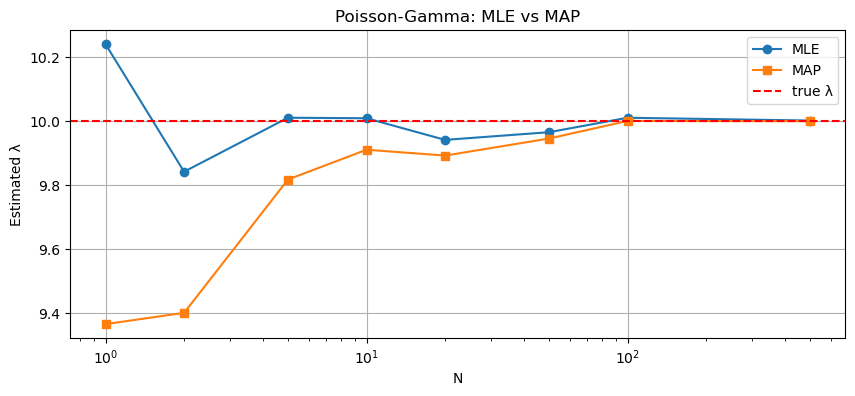

In [15]:
rng = np.random.default_rng(0)

# true lambda
lam_true = 10

# Gamma prior
alpha = 2
beta = 0.2

Ns = [1, 2, 5, 10, 20, 50, 100, 500]

mles = []
maps = []

for N in Ns:

    mle_runs = []
    map_runs = []

    for _ in range(500):

        samples = rng.poisson(lam_true, size=N)

        # MLE
        lam_mle = samples.mean()

        # MAP
        lam_map = (alpha + samples.sum() - 1) / (beta + N)

        mle_runs.append(lam_mle)
        map_runs.append(lam_map)

    mles.append(np.mean(mle_runs))
    maps.append(np.mean(map_runs))

plt.semilogx(Ns, mles, 'o-', label='MLE')
plt.semilogx(Ns, maps, 's-', label='MAP')
plt.axhline(lam_true, color='red', linestyle='--', label='true λ')
plt.xlabel('N')
plt.ylabel('Estimated λ')
plt.title('Poisson-Gamma: MLE vs MAP')
plt.legend()
plt.grid(True)
plt.show()

For small N:
MLE is noisy.
MAP is influenced by the Gamma prior.
For large N:
λMAP≈λMLE